In [1]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [2]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    load_and_detect_onsets,
    plot_waveform_with_onsets,
    inspect_sound_with_repetition,
)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from IPython.display import HTML
audio_style = "<style>audio { margin-left: 23px; width: 720px; }</style>"
display(HTML(audio_style))

### Query examples from Freesound

In [5]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'description', 'name', 'username', 'previews', 'license', 'tags']

In [6]:
FREESOUND_API_KEY = os.getenv('FREESOUND_API_KEY')
FREESOUND_API_KEY = FREESOUND_API_KEY.strip('"')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [7]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [54]:
phrase = '"4 times"'
exclusion_terms = "music loop bass electronic signature synth bpm beat chord tempo stereo"

# 1. Build a query string that handles text exclusions natively
# This transforms into: '"3 times" -music -loop -bass -electronic ...'
query = f"{phrase} " + " ".join([f"-{term}" for term in exclusion_terms.split()])
clean_query = phrase.replace('"', '').lower()  # Leaves us with: '3 times'

# 2. Keep the filter parameter strictly for numeric and scalar ranges
filt = "duration:[0 TO 10] onset_count:[3 TO 20]"

num_results = 40  # Increased since our strict filters will drop several results
# --------------------------------------------------
# Run queries (The rest of your script remains the same)
# --------------------------------------------------
sounds = query_freesound(
        query=query,
        filter=filt,
        client=client,
        fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
        num_results=num_results,
)

print(f"API returned {len(sounds)} potential sound objects.")

# --------------------------------------------------
# LOCAL VERBATIM FILTER (The Guard - Bug Fixed)
# --------------------------------------------------
strict_sounds = []
for sound in sounds:
    name_lower = sound.name.lower()
    
    # Safely fetch the attribute; default to an empty string if it doesn't exist
    description_text = getattr(sound, "description", "")
    desc_lower = description_text.lower() if description_text else ""
    
    # Python strictly checks for the exact phrase with the space and correct pluralization
    if (clean_query in name_lower) or (clean_query in desc_lower):
        strict_sounds.append(sound)

print(f"Locally filtered down to {len(strict_sounds)} strictly verbatim matching sounds.")

API returned 27 potential sound objects.
Locally filtered down to 24 strictly verbatim matching sounds.


In [55]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Download previews
# --------------------------------------------------
subdir_path = AUDIO_DIR + phrase.replace(" ", "-")
for i, sound in enumerate(strict_sounds, 1):
    print(f"[{i}/{len(strict_sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, subdir_path)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(strict_sounds, subdir_path)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(strict_sounds),
    "query": query,
    "subdir_path": subdir_path
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

[1/24] Downloading sound ID 722979
[2/24] Downloading sound ID 684114
[3/24] Downloading sound ID 567757
[4/24] Downloading sound ID 20716
[5/24] Downloading sound ID 14580
[6/24] Downloading sound ID 161326
[7/24] Downloading sound ID 149462
[8/24] Downloading sound ID 110571
[9/24] Downloading sound ID 166901
[10/24] Downloading sound ID 166711
[11/24] Downloading sound ID 724991
[12/24] Downloading sound ID 808367
[13/24] Downloading sound ID 37226
[14/24] Downloading sound ID 444379
[15/24] Downloading sound ID 188631
[16/24] Downloading sound ID 413266
[17/24] Downloading sound ID 324603
[18/24] Downloading sound ID 394863
[19/24] Downloading sound ID 371551
[20/24] Downloading sound ID 321890
[21/24] Downloading sound ID 330601
[22/24] Downloading sound ID 507847
[23/24] Downloading sound ID 403457
[24/24] Downloading sound ID 215831
Saved metadata CSV: ../data/meta/dataset_2026-05-20_14-27-31.csv
Saved query log JSON: ../data/meta/dataset_2026-05-20_14-27-31.json


In [290]:
subdir_path

'../data/audio/"3-times"'

In [56]:
!ls ../data/meta

dataset_2026-05-20_14-27-00.csv   dataset_2026-05-20_14-27-31.csv
dataset_2026-05-20_14-27-00.json  dataset_2026-05-20_14-27-31.json


In [57]:
!ls ../data/audio

'"3-times"'  '"4-times"'


In [51]:
delete_dataset_with_gc(META_DIR + "dataset_2026-05-18_16-18-13.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-05-18_16-18-13.csv
Deleted query file: /workspace/data/meta/dataset_2026-05-18_16-18-13.json
Deleted audio: /workspace/data/audio/"4-times"/722979_15435613-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/368080_2465261-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/444379_958643-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/110571_907124-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/166711_2465261-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/371551_1265752-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/413266_270868-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/684114_907124-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/570274_907124-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/421009_6463913-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/20716_104634-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/567757_907124-hq.ogg
Deleted audio: /workspace/dat

### Show downloaded audio

In [14]:
!ls -lt ../data/audio/'"4-times"'

ls: cannot access '../data/audio/"4-times"': No such file or directory


In [14]:
# select a file manually
filename = "66113_877451-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/66113_877451-hq.ogg'

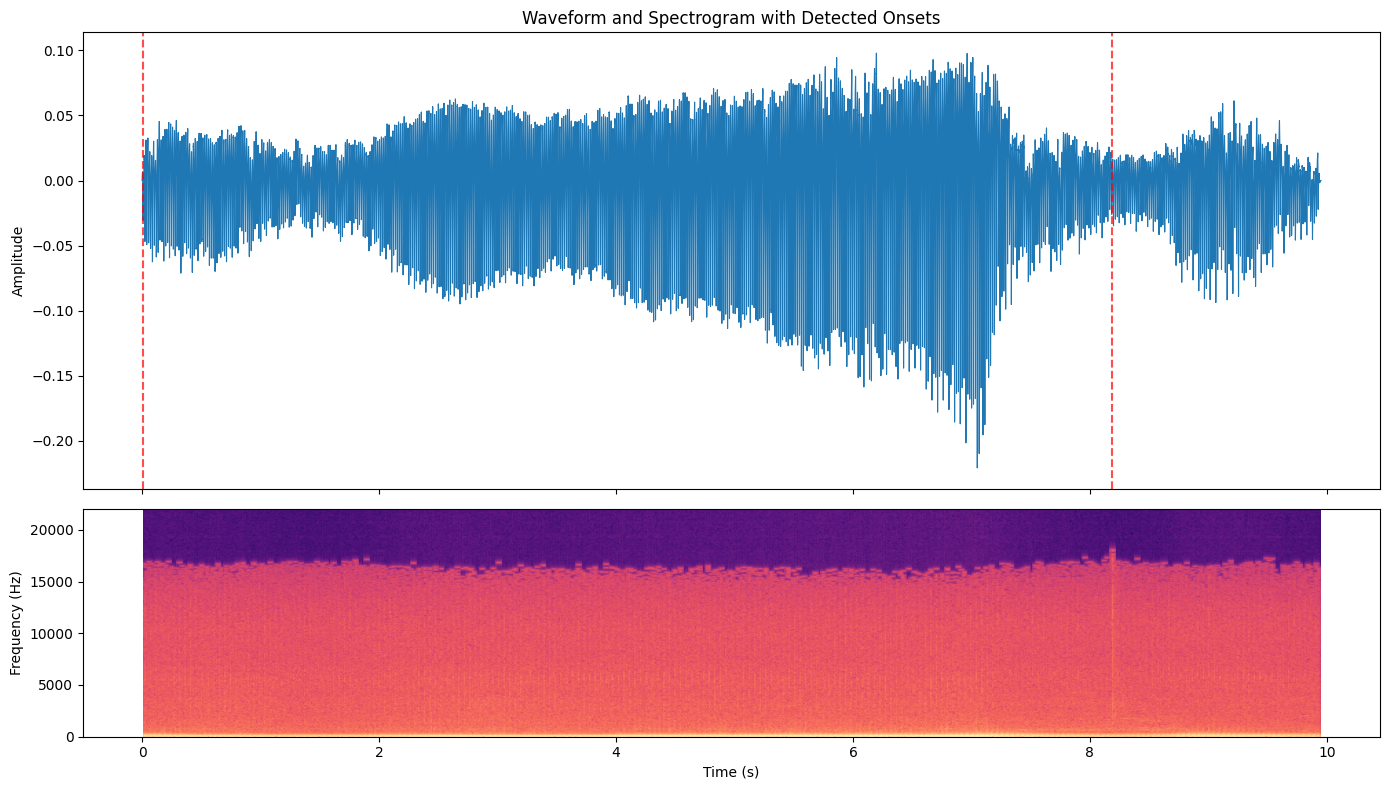

In [15]:
# select a file randomly
subdir = 'electric-fan'
filename = random.choice(os.listdir(AUDIO_DIR + subdir))
filepath = f"{AUDIO_DIR}/{subdir}/{filename}"
sound_id = int(filename[:filename.find("_")])

start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filepath)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)

### Analyze repetitiveness

In [366]:
!ls ../data/audio

'"3-times"'


In [369]:
subdir = '"4-times"'

In [370]:
filenames = os.listdir(f'{AUDIO_DIR}/{subdir}')
freesound_ids = [int(filename[:filename.find("_")]) for filename in filenames]

In [436]:
current_id = freesound_ids[11]

--- Analyzing: 567757_907124-hq.ogg ---
Total raw onsets detected: 4
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 4
--> Found repeating event! Repetitions count: 4

--- Sound ID: 567757 ---
File: 567757_907124-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 4 | In Pattern: 4


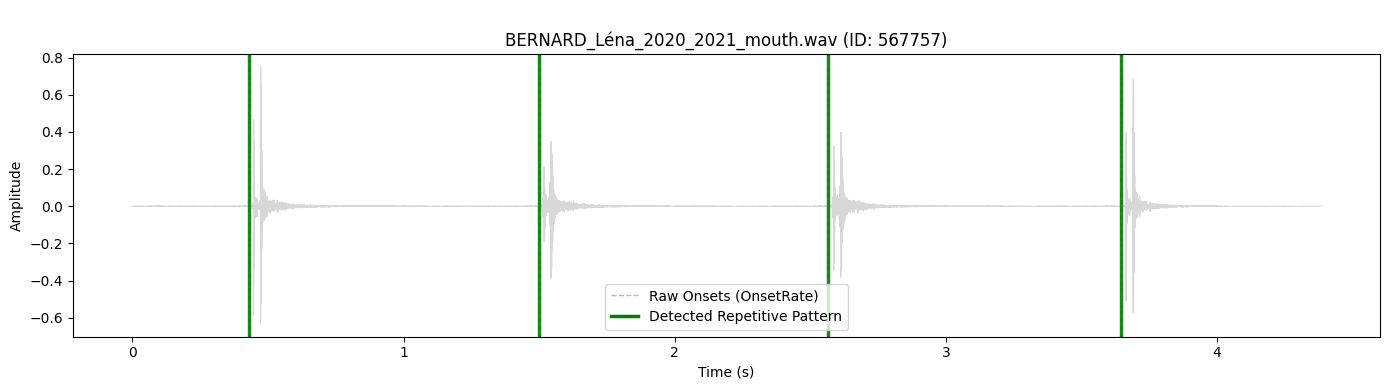

In [437]:
inspect_sound_with_repetition(META_DIR, current_id)

---

### Annotate data

In [132]:
df = None
for csv_path in glob.glob(os.path.join(META_DIR, "dataset_*.csv")):
    print(csv_path)
    if df is None:
        df = pd.read_csv(csv_path)
    else:
        df = pd.concat([df, pd.read_csv(csv_path)])

../data/meta/dataset_2026-05-20_14-27-00.csv
../data/meta/dataset_2026-05-20_14-27-31.csv


In [133]:
len(df)

64

In [83]:
path = df.iloc[0]["local_path"]
audio, onsets = load_and_detect_onsets(path)

In [134]:
df[:5]

,sound_id,name,username,license,tags,preview_url,local_path
0,655124,Dog Barking 3 times.wav,221339,https://creativecommons.org/licenses/by/4.0/,"Animal,Dog,Loud,OWI,Outside,SFX,Small-dog",https://cdn.freesound.org/previews/655/655124_...,"../data/audio/""3-times""/655124_13789330-hq.ogg"
1,722978,Wood Knocking 3 Times,SamsCollegeAccount,http://creativecommons.org/publicdomain/zero/1.0/,"3,aggressive,creepy,knocking,three,wood",https://cdn.freesound.org/previews/722/722978_...,"../data/audio/""3-times""/722978_15435613-hq.ogg"
2,765153,Gun Shot 3 Times,MieckevanHoek,http://creativecommons.org/publicdomain/zero/1.0/,"Gun,OWI,Shooting",https://cdn.freesound.org/previews/765/765153_...,"../data/audio/""3-times""/765153_15764256-hq.ogg"
3,233665,LEGO Shake (3 times),rioforce,http://creativecommons.org/publicdomain/zero/1.0/,"LEGO,bag,brick,click,drop,fall,plastic,shake,toy",https://cdn.freesound.org/previews/233/233665_...,"../data/audio/""3-times""/233665_4067126-hq.ogg"
4,453960,door heavy office wood with metal handle close...,kyles,http://creativecommons.org/publicdomain/zero/1.0/,"3,close,door,handle,heavy,metal,office,rattle,...",https://cdn.freesound.org/previews/453/453960_...,"../data/audio/""3-times""/453960_612689-hq.ogg"


In [79]:
onsets

array([0.5340589, 2.2639456, 3.8196826, 4.376961 , 4.667211 ],
      dtype=float32)

In [138]:
annotations = {}
i = 0

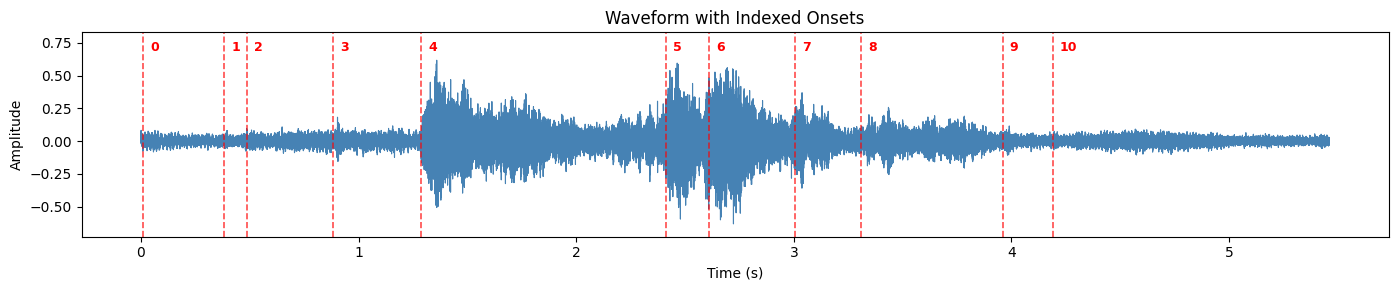

Repetitive onset indices:  4, 5, 6


Repetitive onsets for 468527: [4, 5, 6]


In [175]:
path = df.iloc[i]["local_path"]
audio, onsets = load_and_detect_onsets(path)
plot_waveform_with_onsets(audio, onsets, show_spectrogram=False)
ipd.display(ipd.Audio(audio, rate=44100))
rep_onset_indices = input("Repetitive onset indices: ")
rep_onset_indices = rep_onset_indices.strip().split(",")
rep_onset_indices = [int(idx) for idx in rep_onset_indices if idx]
print(f"Repetitive onsets for {df.iloc[i]['sound_id']}: {rep_onset_indices}")
annotations[int(df.iloc[i]['sound_id'])] = rep_onset_indices
i += 1

In [176]:
annotations

{655124: [0, 1, 2],
 722978: [0, 1, 2],
 765153: [0, 1, 2],
 233665: [0, 2, 4],
 453960: [0, 2, 4],
 755431: [],
 609340: [0, 1, 2],
 156844: [1, 3, 5],
 79250: [1, 3, 4],
 808512: [],
 669285: [0, 3, 6, 9, 12],
 669253: [0, 2, 3],
 608834: [0, 1, 2, 3, 4],
 408096: [1, 4, 7],
 619592: [0, 6, 9],
 567860: [],
 740073: [2, 6, 9],
 653909: [0, 1, 2],
 31748: [0, 1, 2],
 686313: [0, 1, 2],
 854494: [0, 4, 7],
 37807: [],
 444310: [0, 2, 5],
 185930: [2, 4, 7],
 268544: [0, 1, 2],
 244488: [],
 262995: [0, 1, 2, 3, 4, 5, 6, 7, 8],
 677157: [],
 166348: [0, 4, 8, 12],
 199446: [0, 1, 2],
 241290: [11, 12, 13],
 514233: [2, 7, 12, 17],
 571282: [2, 6, 9],
 468527: [4, 5, 6]}

In [178]:
df

,sound_id,name,username,license,tags,preview_url,local_path
0,655124,Dog Barking 3 times.wav,221339,https://creativecommons.org/licenses/by/4.0/,"Animal,Dog,Loud,OWI,Outside,SFX,Small-dog",https://cdn.freesound.org/previews/655/655124_...,"../data/audio/""3-times""/655124_13789330-hq.ogg"
1,722978,Wood Knocking 3 Times,SamsCollegeAccount,http://creativecommons.org/publicdomain/zero/1.0/,"3,aggressive,creepy,knocking,three,wood",https://cdn.freesound.org/previews/722/722978_...,"../data/audio/""3-times""/722978_15435613-hq.ogg"
2,765153,Gun Shot 3 Times,MieckevanHoek,http://creativecommons.org/publicdomain/zero/1.0/,"Gun,OWI,Shooting",https://cdn.freesound.org/previews/765/765153_...,"../data/audio/""3-times""/765153_15764256-hq.ogg"
3,233665,LEGO Shake (3 times),rioforce,http://creativecommons.org/publicdomain/zero/1.0/,"LEGO,bag,brick,click,drop,fall,plastic,shake,toy",https://cdn.freesound.org/previews/233/233665_...,"../data/audio/""3-times""/233665_4067126-hq.ogg"
4,453960,door heavy office wood with metal handle close...,kyles,http://creativecommons.org/publicdomain/zero/1.0/,"3,close,door,handle,heavy,metal,office,rattle,...",https://cdn.freesound.org/previews/453/453960_...,"../data/audio/""3-times""/453960_612689-hq.ogg"
...,...,...,...,...,...,...,...
19,321890,Old clock,Duasun,http://creativecommons.org/publicdomain/zero/1.0/,"clock,clockwork,wall-clock",https://cdn.freesound.org/previews/321/321890_...,"../data/audio/""4-times""/321890_5503971-hq.ogg"
20,330601,CELL PHONE DBL BEEP NOTIFICATION.wav,diniunicorn,http://creativecommons.org/publicdomain/zero/1.0/,"CELL-PHONE,DOUBLE-BEEP,EMAIL-NOTIFICATION,MOBI...",https://cdn.freesound.org/previews/330/330601_...,"../data/audio/""4-times""/330601_5749072-hq.ogg"
21,507847,Hard anger knocking with added reverb,Rvgerxini,http://creativecommons.org/publicdomain/zero/1.0/,"anger,angry,bashing,echo,echos,hard,hardwood,h...",https://cdn.freesound.org/previews/507/507847_...,"../data/audio/""4-times""/507847_9453283-hq.ogg"
22,403457,carr_pit4.wav,anez,https://creativecommons.org/licenses/by/4.0/,"4,bocina,car,horn,pito,times",https://cdn.freesound.org/previews/403/403457_...,"../data/audio/""4-times""/403457_7826204-hq.ogg"


In [8]:
def evaluate_pipeline(ground_truth, meta_dir):
    """
    ground_truth: dict mapping sound_id -> list of true indices, e.g. {655124: [0, 1, 2]}
    """
    total_true = 0
    total_pred = 0
    total_hits = 0
    
    for sound_id, true_indices in ground_truth.items():
        # Temporarily suppress the plots if you just want the math (or let them render!)
        pred_indices = inspect_sound_with_repetition(meta_dir, sound_id)
        
        true_set = set(true_indices)
        pred_set = set(pred_indices)
        
        hits = len(true_set.intersection(pred_set))
        
        total_true += len(true_set)
        total_pred += len(pred_set)
        total_hits += hits
        
    precision = total_hits / total_pred if total_pred > 0 else 0
    recall = total_hits / total_true if total_true > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\n=== FINAL EVALUATION ===")
    print(f"Precision: {precision:.2f} (When pipeline fired, it was right {precision*100:.0f}% of the time)")
    print(f"Recall:    {recall:.2f} (Pipeline found {recall*100:.0f}% of all true repetitive onsets)")
    print(f"F1 Score:  {f1:.2f}")

# evaluate_pipeline(my_annotations_dict, "./metadata")

In [11]:
annotations = eval("""
{655124: [0, 1, 2],
 722978: [0, 1, 2],
 765153: [0, 1, 2],
 233665: [0, 2, 4],
 453960: [0, 2, 4],
 755431: [],
 609340: [0, 1, 2],
 156844: [1, 3, 5],
 79250: [1, 3, 4],
 808512: [],
 669285: [0, 3, 6, 9, 12],
 669253: [0, 2, 3],
 608834: [0, 1, 2, 3, 4],
 408096: [1, 4, 7],
 619592: [0, 6, 9],
 567860: [],
 740073: [2, 6, 9],
 653909: [0, 1, 2],
 31748: [0, 1, 2],
 686313: [0, 1, 2],
 854494: [0, 4, 7],
 37807: [],
 444310: [0, 2, 5],
 185930: [2, 4, 7],
 268544: [0, 1, 2],
 244488: [],
 262995: [0, 1, 2, 3, 4, 5, 6, 7, 8],
 677157: [],
 166348: [0, 4, 8, 12],
 199446: [0, 1, 2],
 241290: [11, 12, 13],
 514233: [2, 7, 12, 17],
 571282: [2, 6, 9],
 468527: [4, 5, 6]}
""")

--- Analyzing: 655124_13789330-hq.ogg ---
Total raw onsets detected: 5
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 1
Not enough percussive/decaying events to cluster.

--- Sound ID: 655124 ---
File: 655124_13789330-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 5 | In Pattern: 0
Detected Repetitive Indices: []


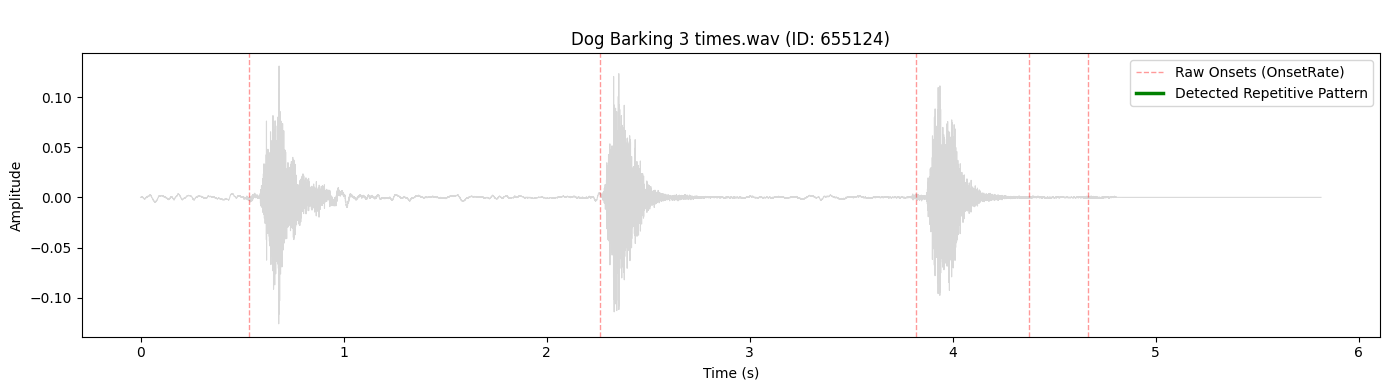

--- Analyzing: 722978_15435613-hq.ogg ---
Total raw onsets detected: 3
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 722978 ---
File: 722978_15435613-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 2]


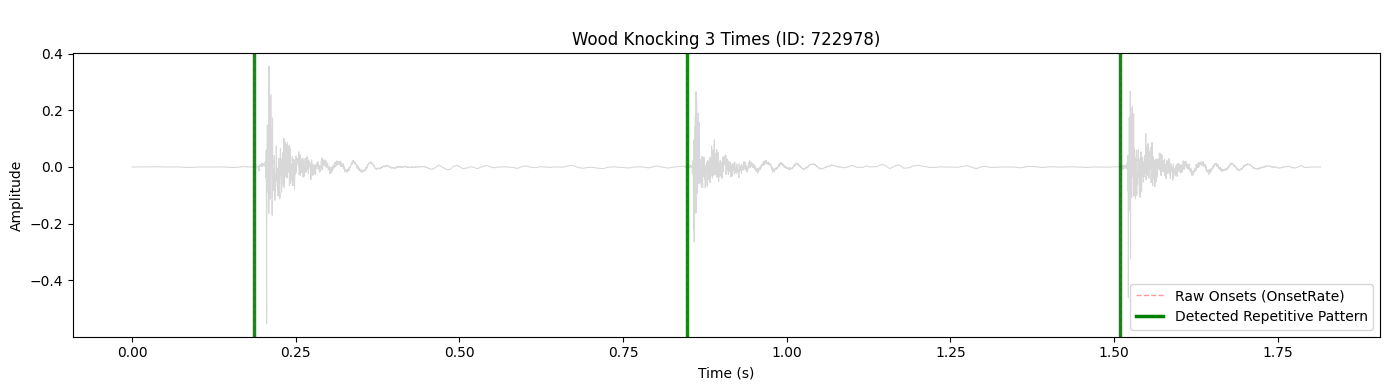

--- Analyzing: 765153_15764256-hq.ogg ---
Total raw onsets detected: 3
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 765153 ---
File: 765153_15764256-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 2]


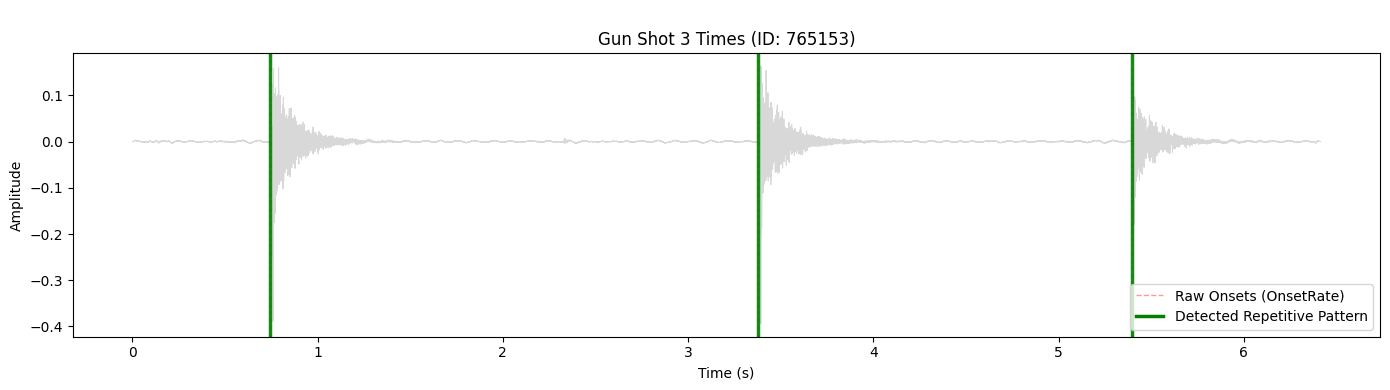

--- Analyzing: 233665_4067126-hq.ogg ---
Total raw onsets detected: 5
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 5
--> Found repeating event! Repetitions count: 4

--- Sound ID: 233665 ---
File: 233665_4067126-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 5 | In Pattern: 4
Detected Repetitive Indices: [0, 1, 2, 3]


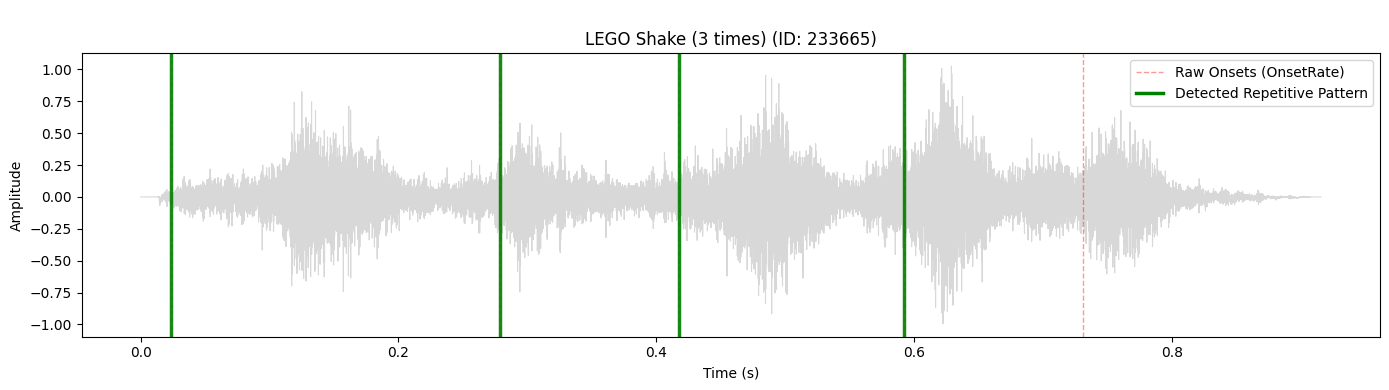

--- Analyzing: 453960_612689-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 1
Not enough percussive/decaying events to cluster.

--- Sound ID: 453960 ---
File: 453960_612689-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 6 | In Pattern: 0
Detected Repetitive Indices: []


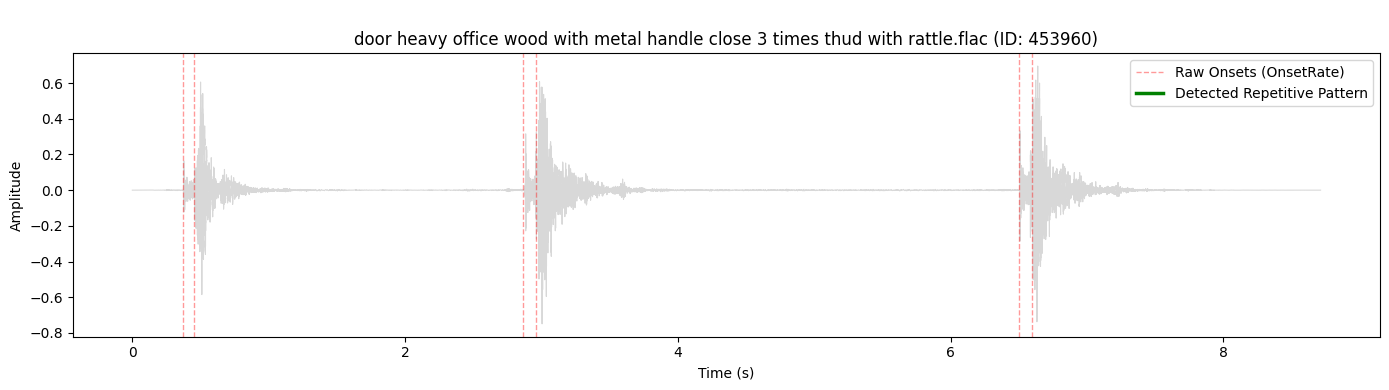

--- Analyzing: 755431_16347648-hq.ogg ---
Total raw onsets detected: 9
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 1
Not enough percussive/decaying events to cluster.

--- Sound ID: 755431 ---
File: 755431_16347648-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 9 | In Pattern: 0
Detected Repetitive Indices: []


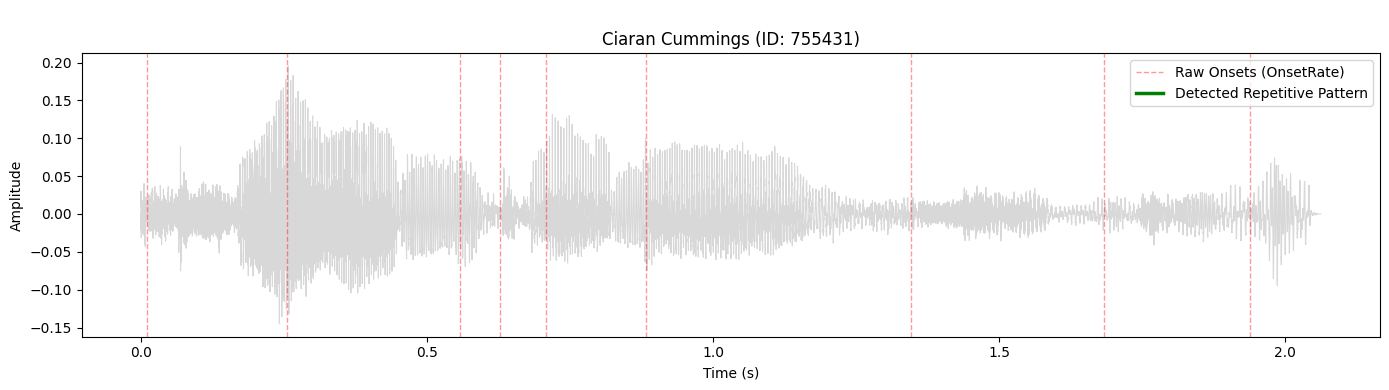

--- Analyzing: 609340_11206457-hq.ogg ---
Total raw onsets detected: 3
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 609340 ---
File: 609340_11206457-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 0
Detected Repetitive Indices: []


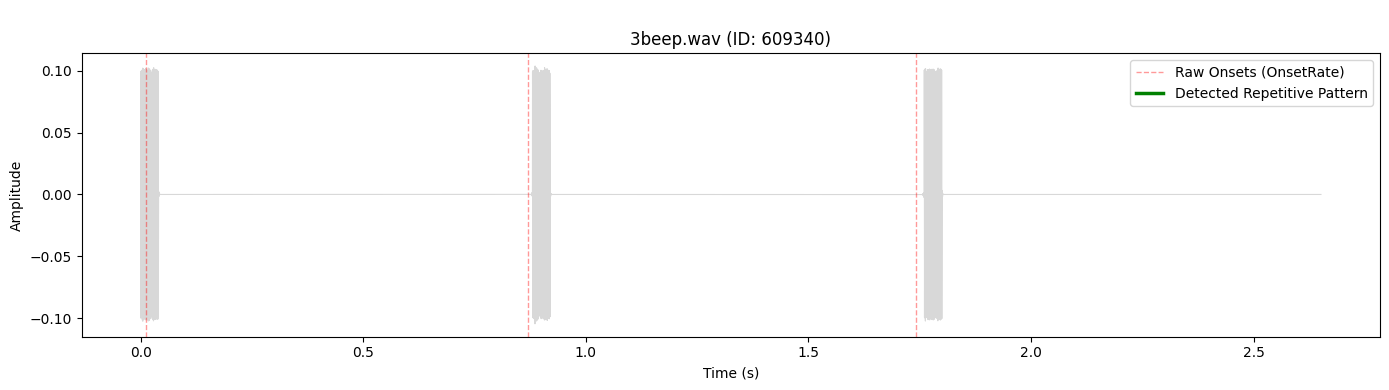

--- Analyzing: 156844_937808-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> No repeating clusters found.

--- Sound ID: 156844 ---
File: 156844_937808-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 6 | In Pattern: 0
Detected Repetitive Indices: []


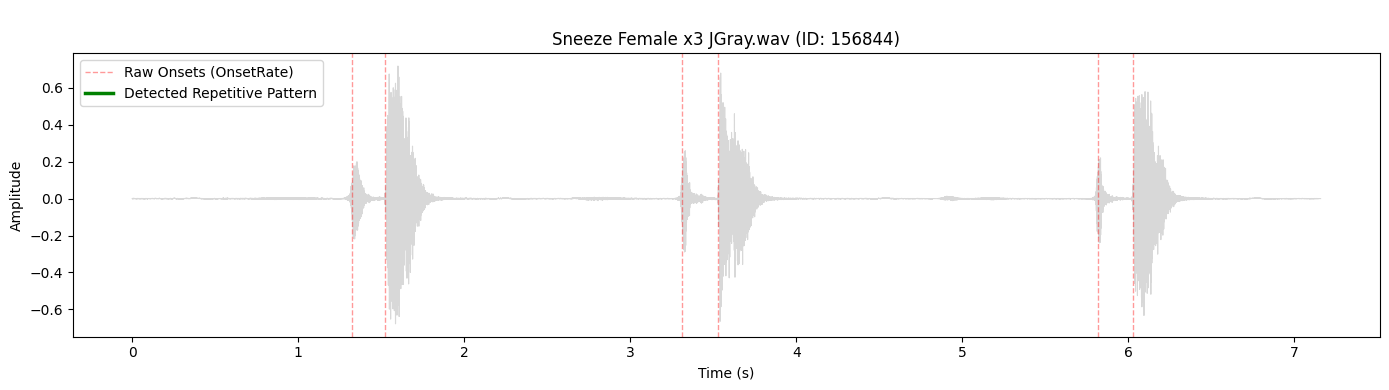

--- Analyzing: 79250_988961-hq.ogg ---
Total raw onsets detected: 5
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 79250 ---
File: 79250_988961-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 5 | In Pattern: 0
Detected Repetitive Indices: []


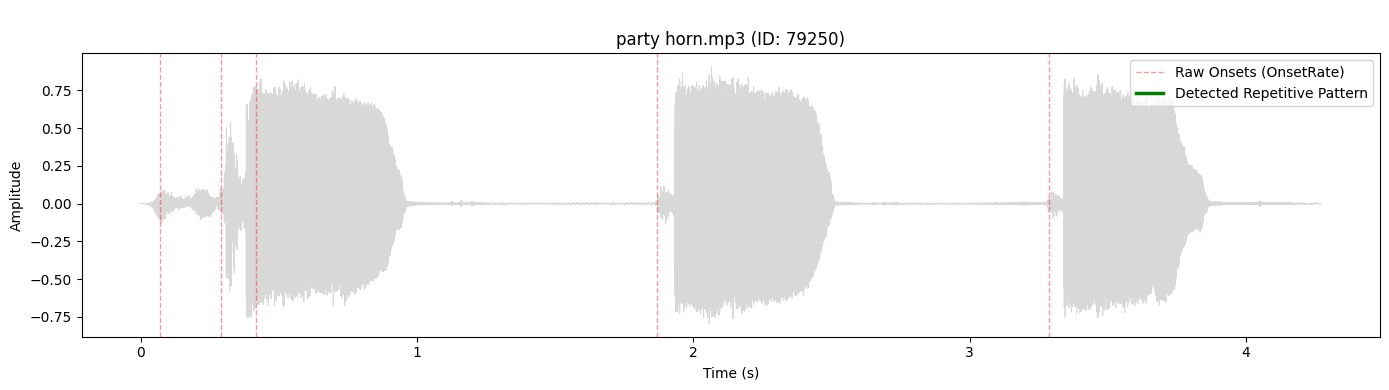

--- Analyzing: 808512_3797507-hq.ogg ---
Total raw onsets detected: 7
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 808512 ---
File: 808512_3797507-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 7 | In Pattern: 0
Detected Repetitive Indices: []


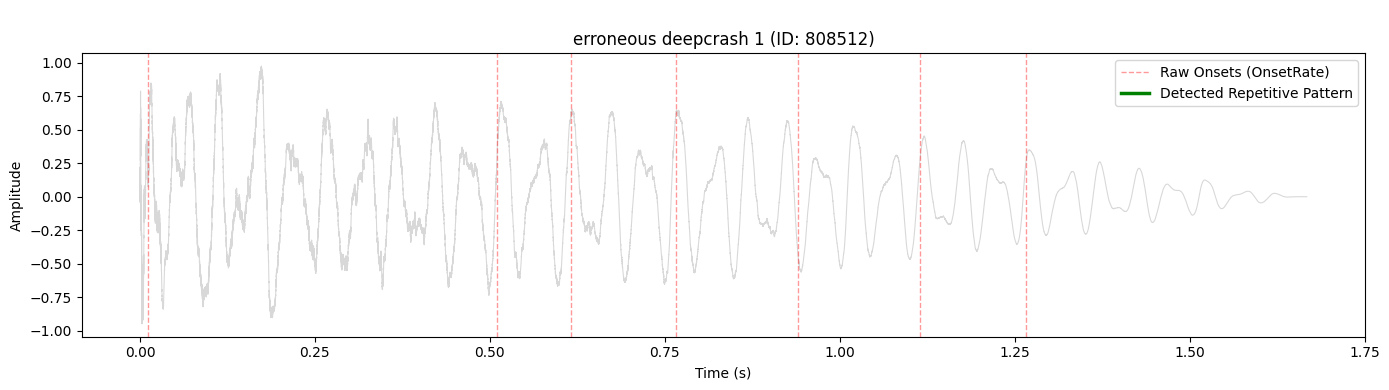

--- Analyzing: 669285_556505-hq.ogg ---
Total raw onsets detected: 15
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 12
--> Found repeating event! Repetitions count: 12

--- Sound ID: 669285 ---
File: 669285_556505-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 15 | In Pattern: 12
Detected Repetitive Indices: [0, 1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 14]


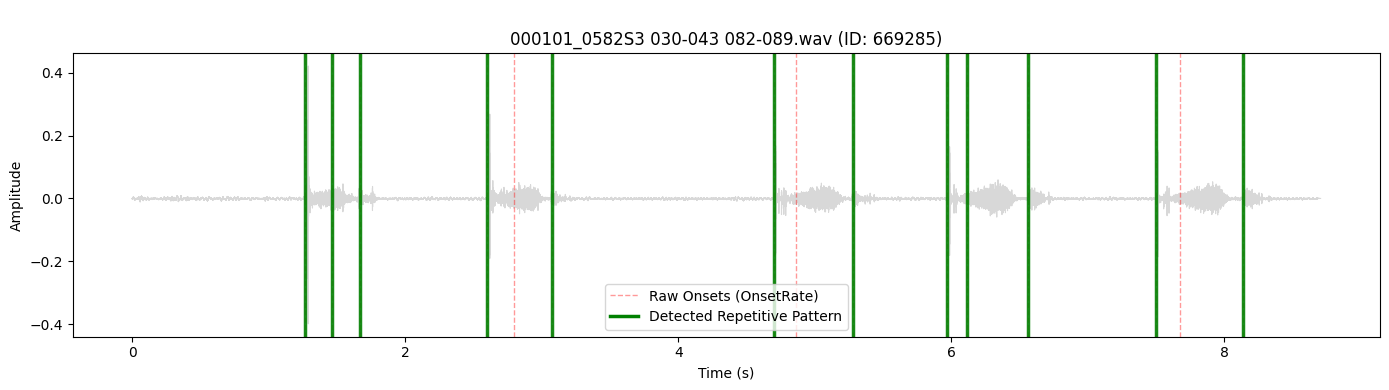

--- Analyzing: 669253_556505-hq.ogg ---
Total raw onsets detected: 5
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 4
--> Found repeating event! Repetitions count: 3

--- Sound ID: 669253 ---
File: 669253_556505-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 5 | In Pattern: 3
Detected Repetitive Indices: [0, 2, 3]


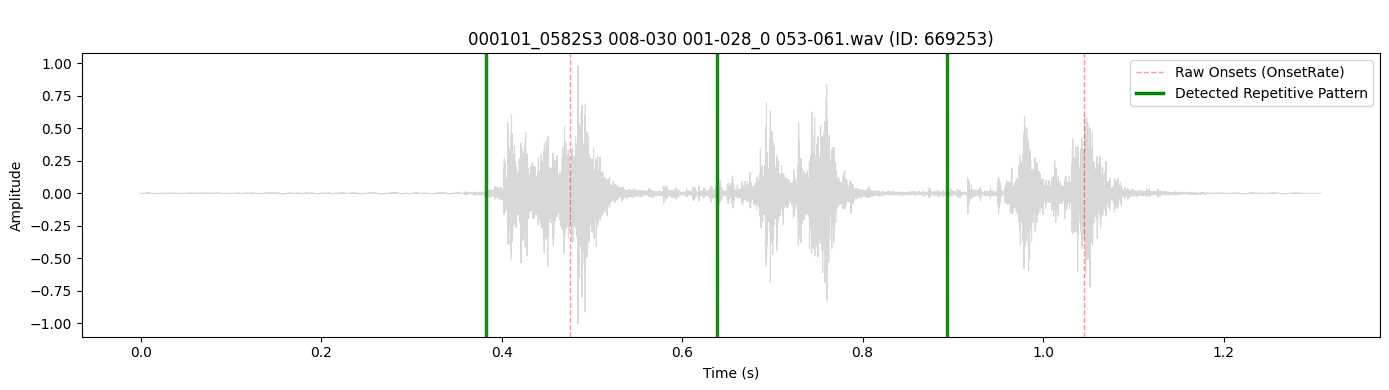

--- Analyzing: 608834_13137106-hq.ogg ---
Total raw onsets detected: 6
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 608834 ---
File: 608834_13137106-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 6 | In Pattern: 0
Detected Repetitive Indices: []


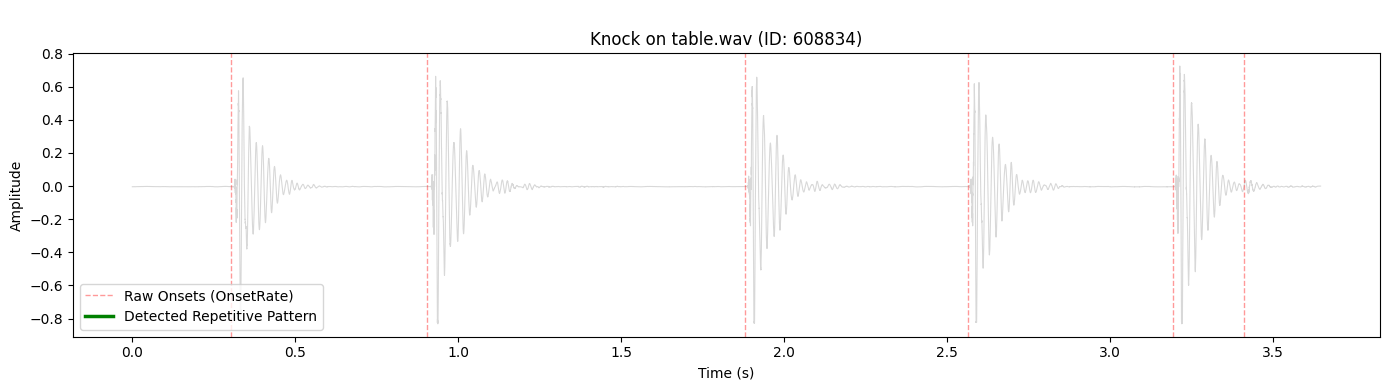

--- Analyzing: 408096_6691314-hq.ogg ---
Total raw onsets detected: 8
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 2
--> No repeating clusters found.

--- Sound ID: 408096 ---
File: 408096_6691314-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 8 | In Pattern: 0
Detected Repetitive Indices: []


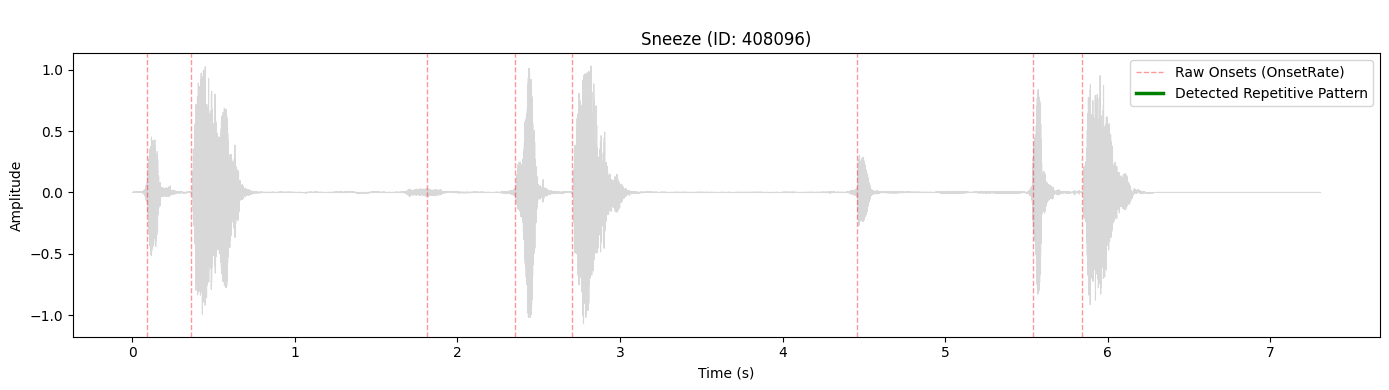

--- Analyzing: 619592_3439106-hq.ogg ---
Total raw onsets detected: 14
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 12
--> Found repeating event! Repetitions count: 10

--- Sound ID: 619592 ---
File: 619592_3439106-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 14 | In Pattern: 10
Detected Repetitive Indices: [1, 2, 4, 5, 6, 7, 9, 10, 11, 13]


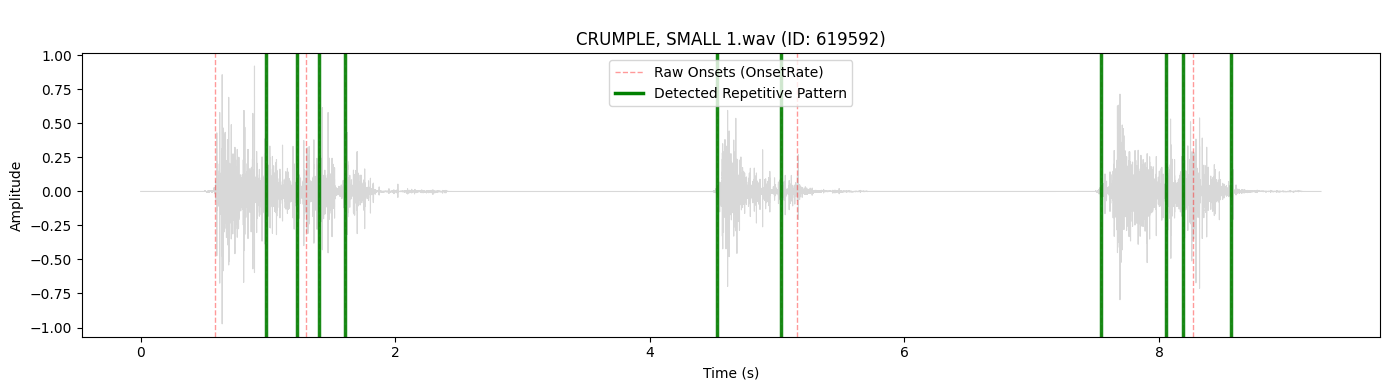

--- Analyzing: 567860_907124-hq.ogg ---
Total raw onsets detected: 11
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 5
--> Found repeating event! Repetitions count: 5

--- Sound ID: 567860 ---
File: 567860_907124-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 11 | In Pattern: 5
Detected Repetitive Indices: [4, 7, 8, 9, 10]


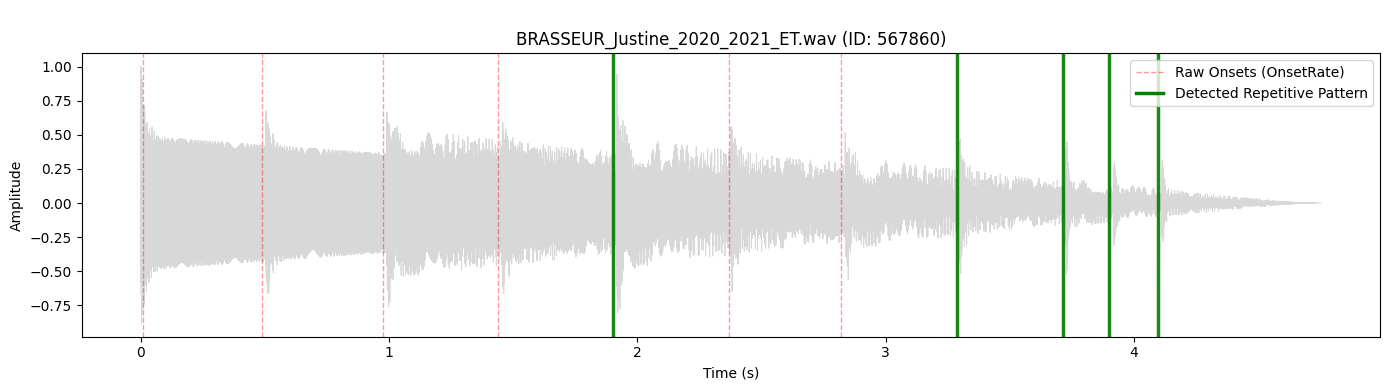

--- Analyzing: 740073_14631530-hq.ogg ---
Total raw onsets detected: 10
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 9
--> Found repeating event! Repetitions count: 9

--- Sound ID: 740073 ---
File: 740073_14631530-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 10 | In Pattern: 9
Detected Repetitive Indices: [0, 1, 2, 3, 5, 6, 7, 8, 9]


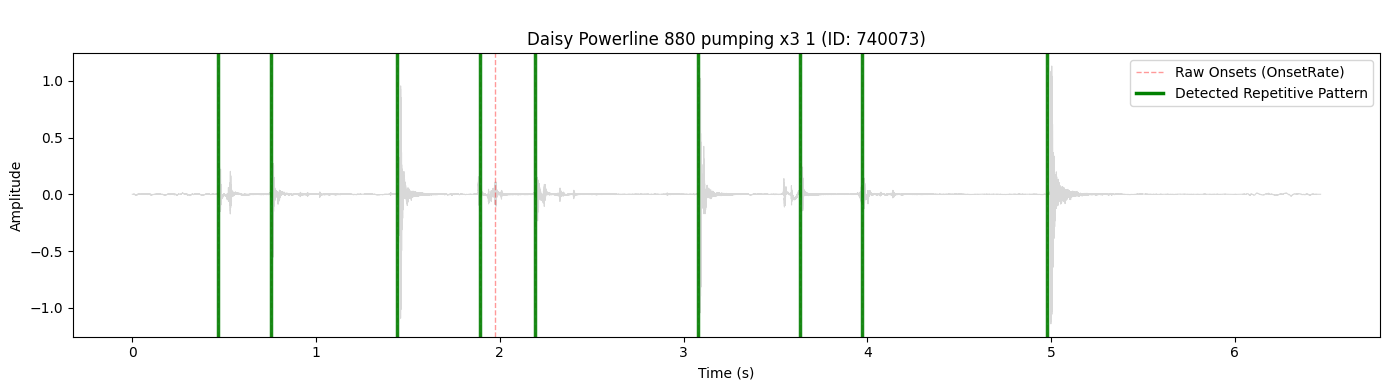

--- Analyzing: 653909_13579627-hq.ogg ---
Total raw onsets detected: 3
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 653909 ---
File: 653909_13579627-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 0
Detected Repetitive Indices: []


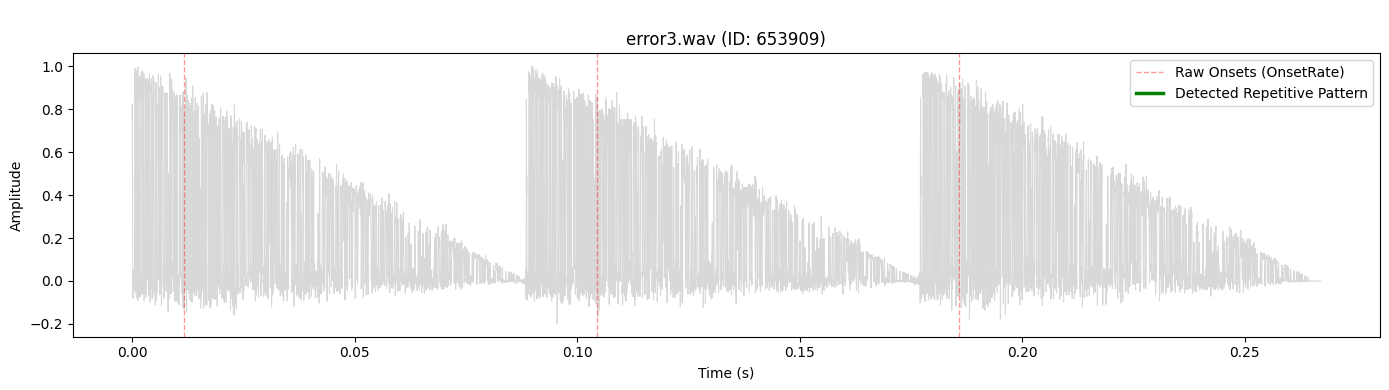

--- Analyzing: 31748_29541-hq.ogg ---
Total raw onsets detected: 3
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 31748 ---
File: 31748_29541-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 2]


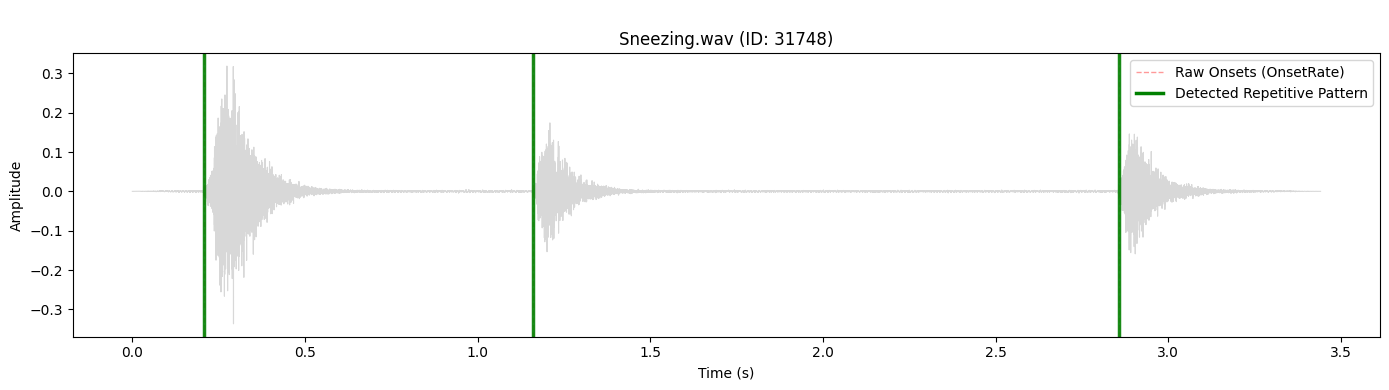

--- Analyzing: 686313_13355471-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 686313 ---
File: 686313_13355471-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 6 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 3]


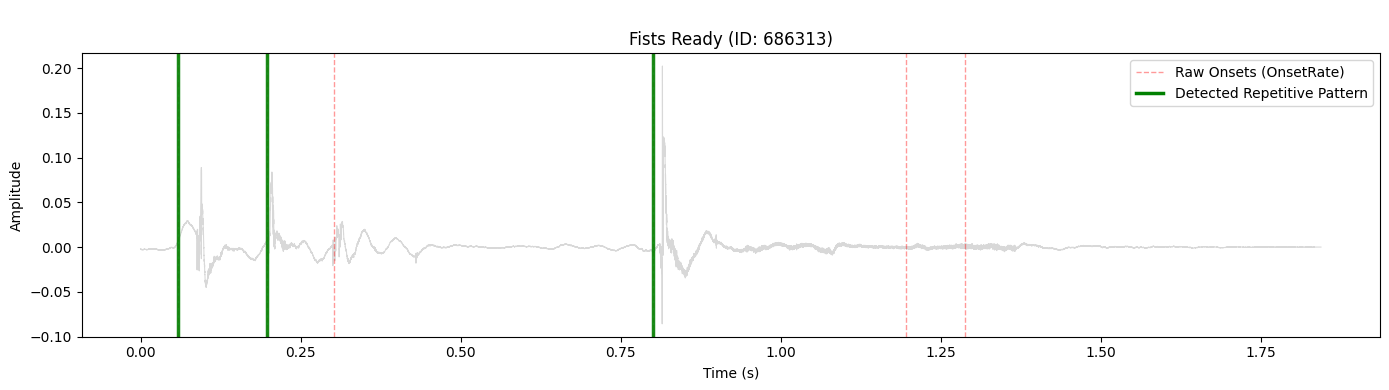

--- Analyzing: 854494_7157894-hq.ogg ---
Total raw onsets detected: 10
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 6
--> No repeating clusters found.

--- Sound ID: 854494 ---
File: 854494_7157894-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 10 | In Pattern: 0
Detected Repetitive Indices: []


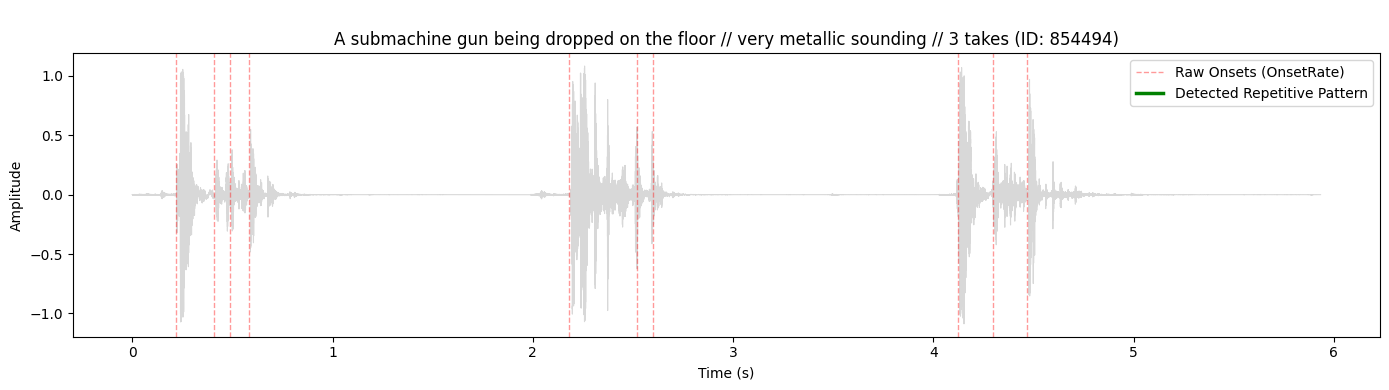

--- Analyzing: 37807_145905-hq.ogg ---
Total raw onsets detected: 11
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 2
--> No repeating clusters found.

--- Sound ID: 37807 ---
File: 37807_145905-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 11 | In Pattern: 0
Detected Repetitive Indices: []


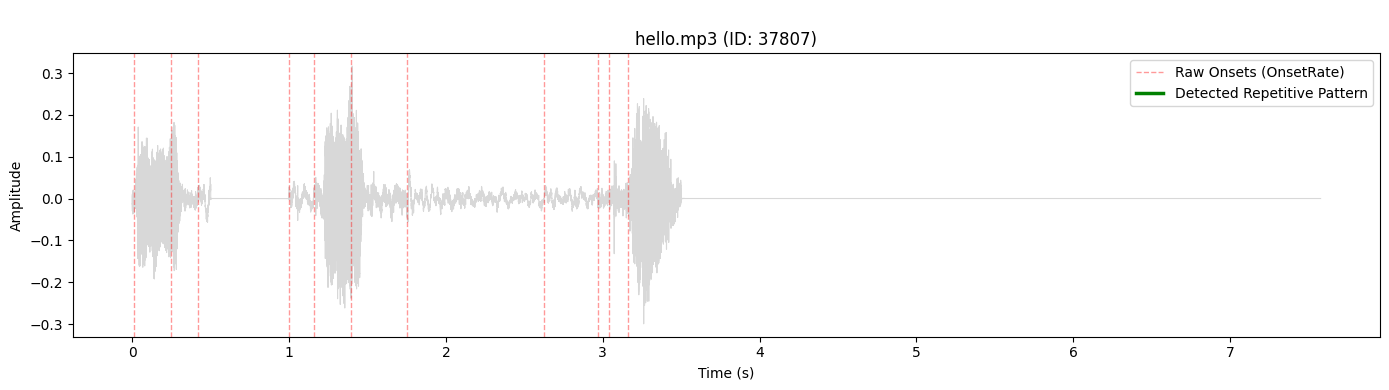

--- Analyzing: 444310_5703859-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 1
Not enough percussive/decaying events to cluster.

--- Sound ID: 444310 ---
File: 444310_5703859-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 6 | In Pattern: 0
Detected Repetitive Indices: []


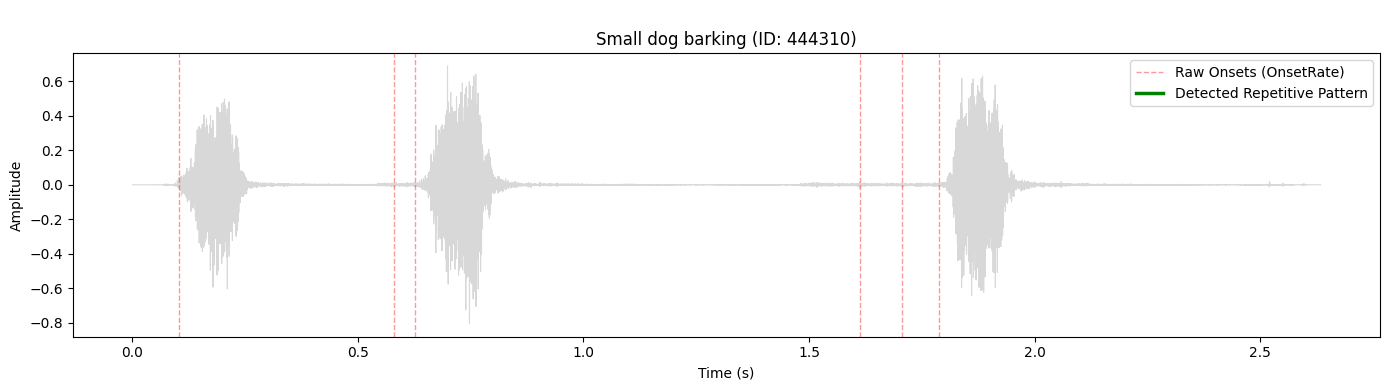

--- Analyzing: 185930_2833773-hq.ogg ---
Total raw onsets detected: 10
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 185930 ---
File: 185930_2833773-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 10 | In Pattern: 3
Detected Repetitive Indices: [1, 4, 7]


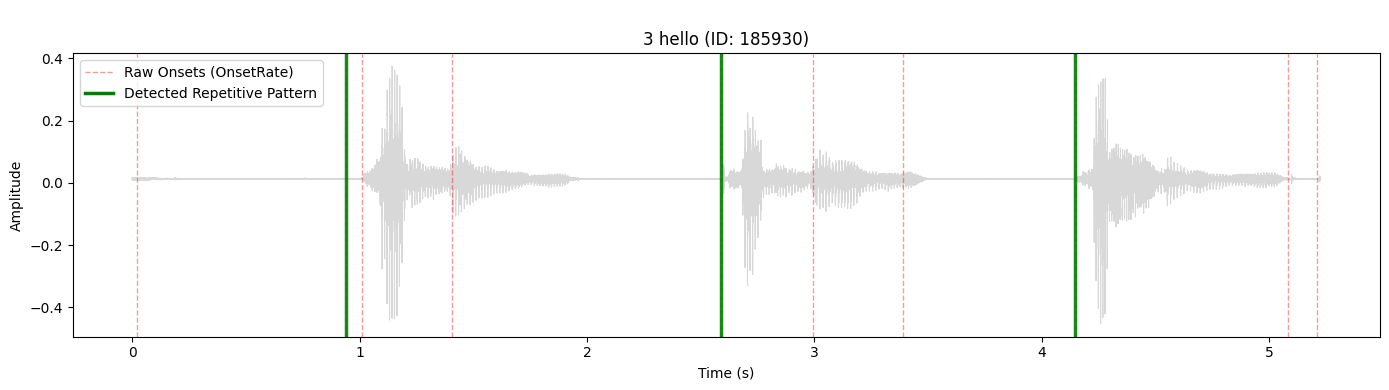

--- Analyzing: 268544_4665183-hq.ogg ---
Total raw onsets detected: 3
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 268544 ---
File: 268544_4665183-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 2]


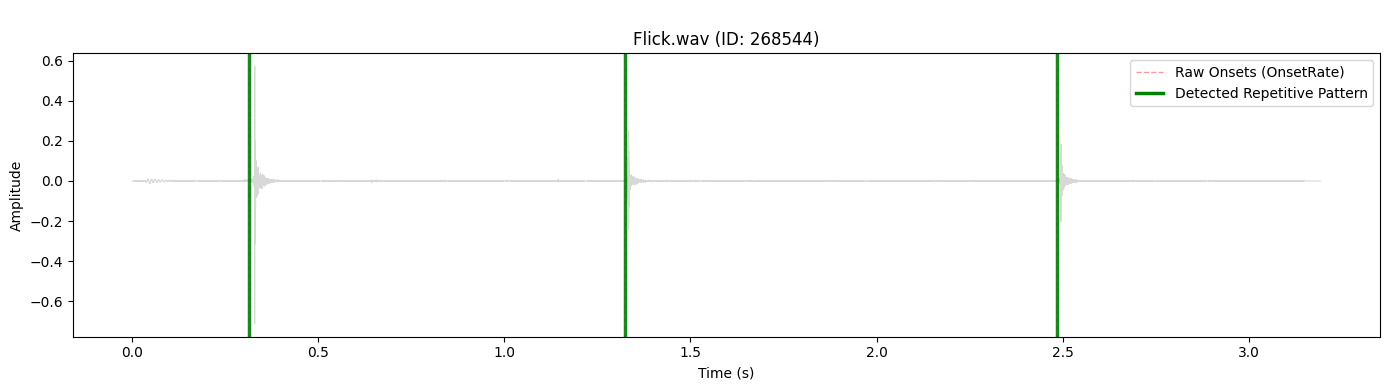

--- Analyzing: 244488_1449999-hq.ogg ---
Total raw onsets detected: 9
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 9
--> Found repeating event! Repetitions count: 6

--- Sound ID: 244488 ---
File: 244488_1449999-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 9 | In Pattern: 6
Detected Repetitive Indices: [2, 3, 4, 5, 6, 7]


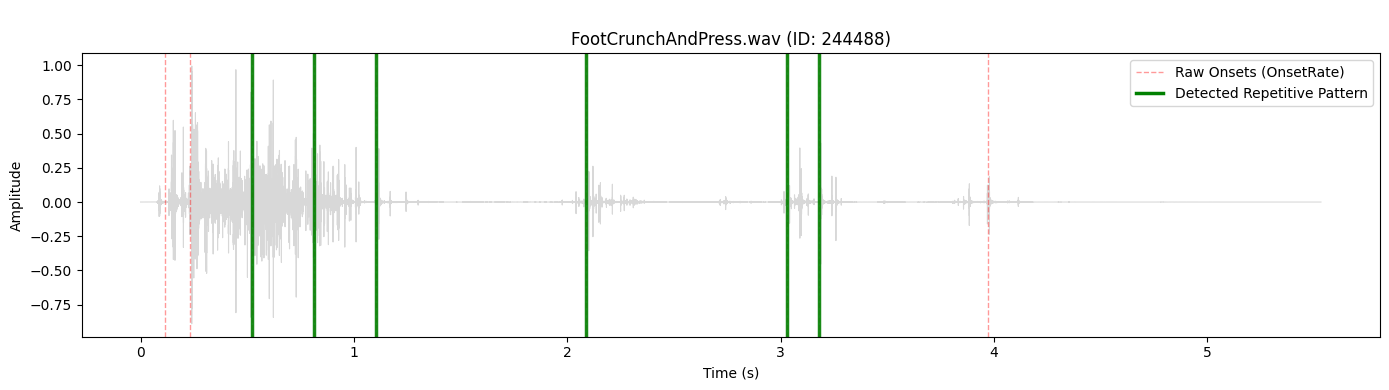

--- Analyzing: 262995_907124-hq.ogg ---
Total raw onsets detected: 10
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 262995 ---
File: 262995_907124-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 10 | In Pattern: 0
Detected Repetitive Indices: []


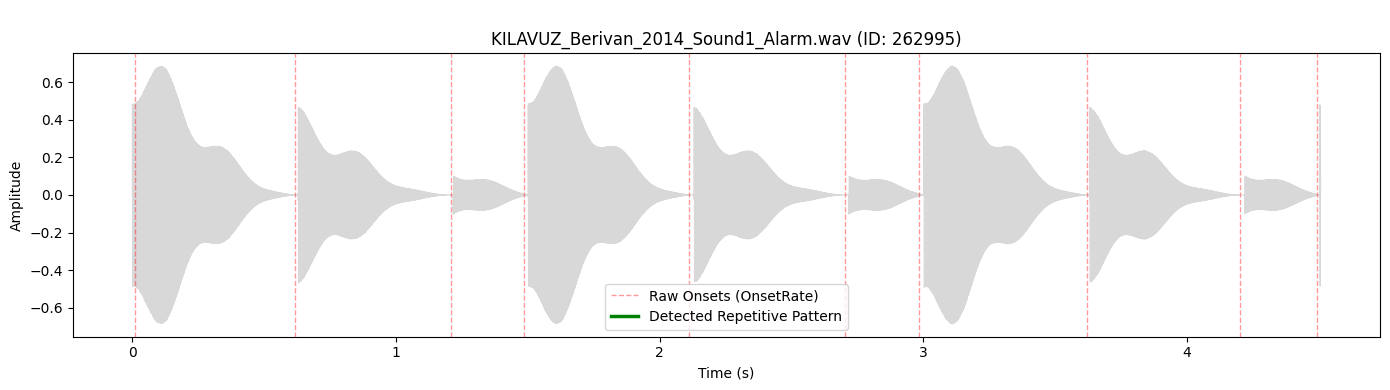

--- Analyzing: 677157_7157894-hq.ogg ---
Total raw onsets detected: 8
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 8
--> Found repeating event! Repetitions count: 8

--- Sound ID: 677157 ---
File: 677157_7157894-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 8 | In Pattern: 8
Detected Repetitive Indices: [0, 1, 2, 3, 4, 5, 6, 7]


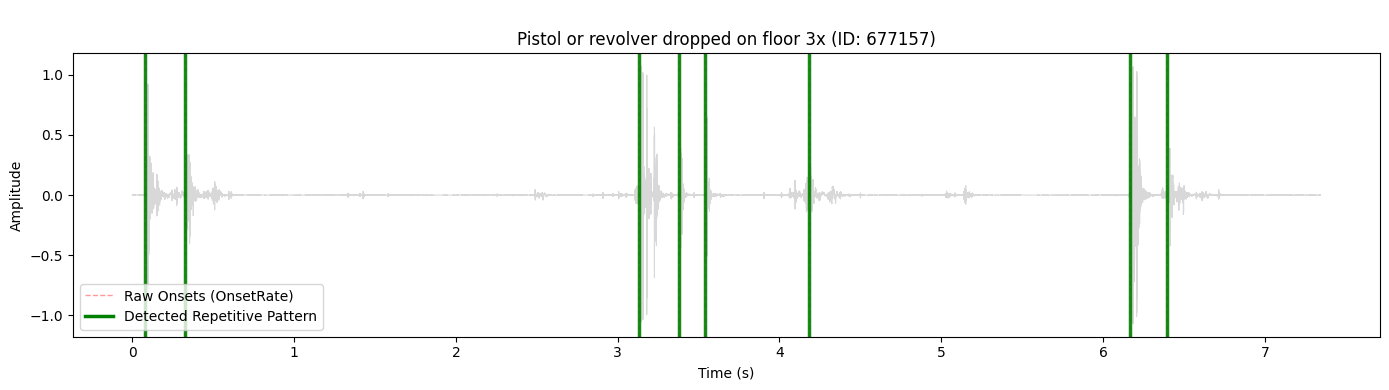

--- Analyzing: 166348_907124-hq.ogg ---
Total raw onsets detected: 16
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 166348 ---
File: 166348_907124-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 16 | In Pattern: 0
Detected Repetitive Indices: []


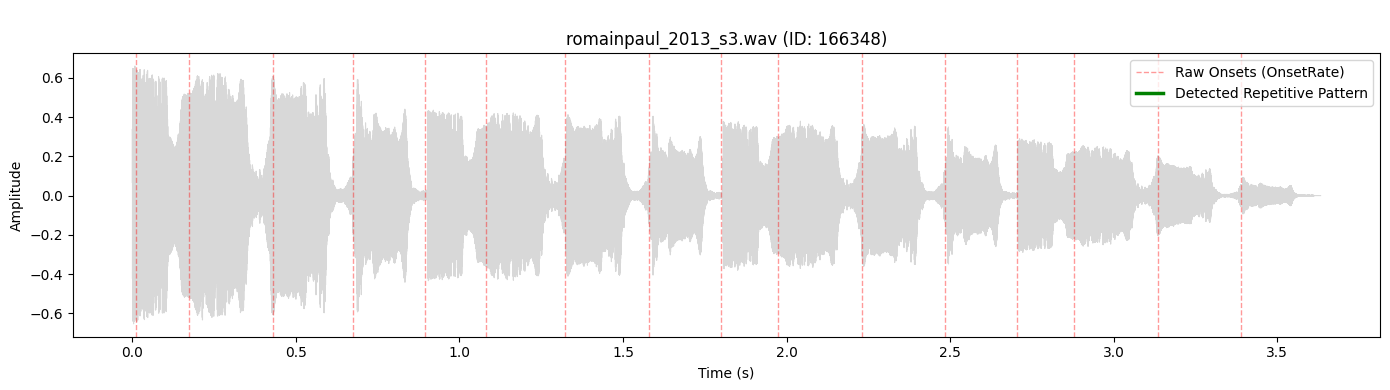

--- Analyzing: 199446_2320755-hq.ogg ---
Total raw onsets detected: 3
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 3
--> Found repeating event! Repetitions count: 3

--- Sound ID: 199446 ---
File: 199446_2320755-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 3 | In Pattern: 3
Detected Repetitive Indices: [0, 1, 2]


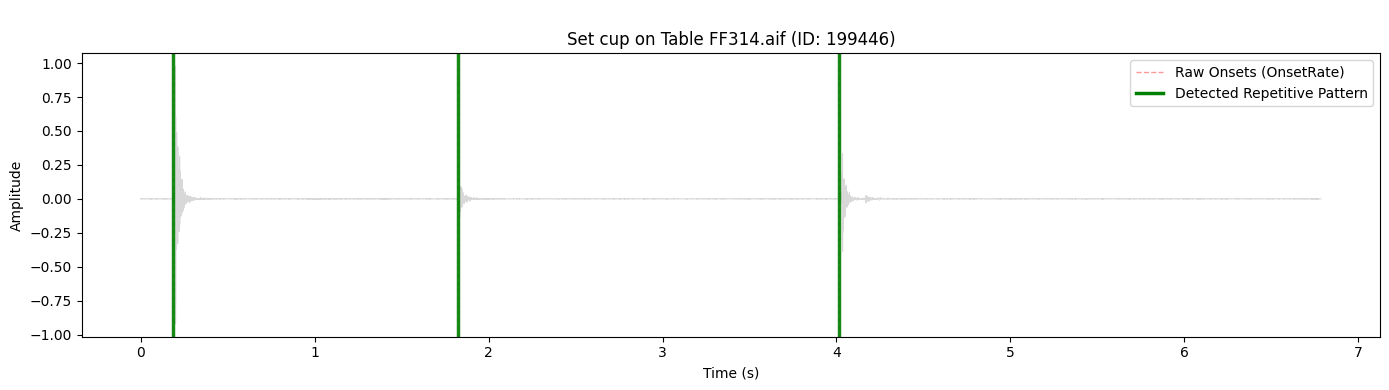

--- Analyzing: 241290_3146873-hq.ogg ---
Total raw onsets detected: 16
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 15
--> Found repeating event! Repetitions count: 15

--- Sound ID: 241290 ---
File: 241290_3146873-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 16 | In Pattern: 15
Detected Repetitive Indices: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


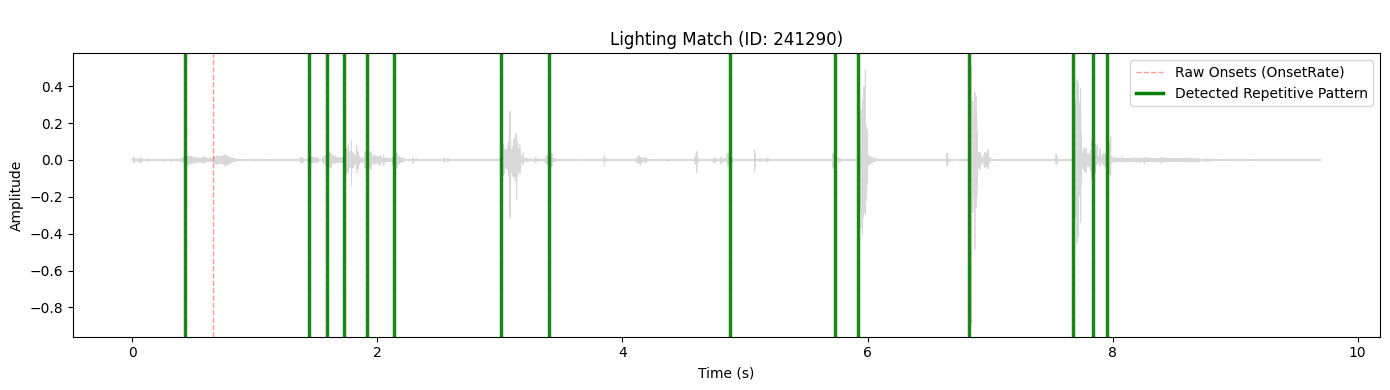

--- Analyzing: 514233_907124-hq.ogg ---
Total raw onsets detected: 20
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 12
--> Found repeating event! Repetitions count: 4

--- Sound ID: 514233 ---
File: 514233_907124-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 20 | In Pattern: 4
Detected Repetitive Indices: [0, 5, 10, 15]


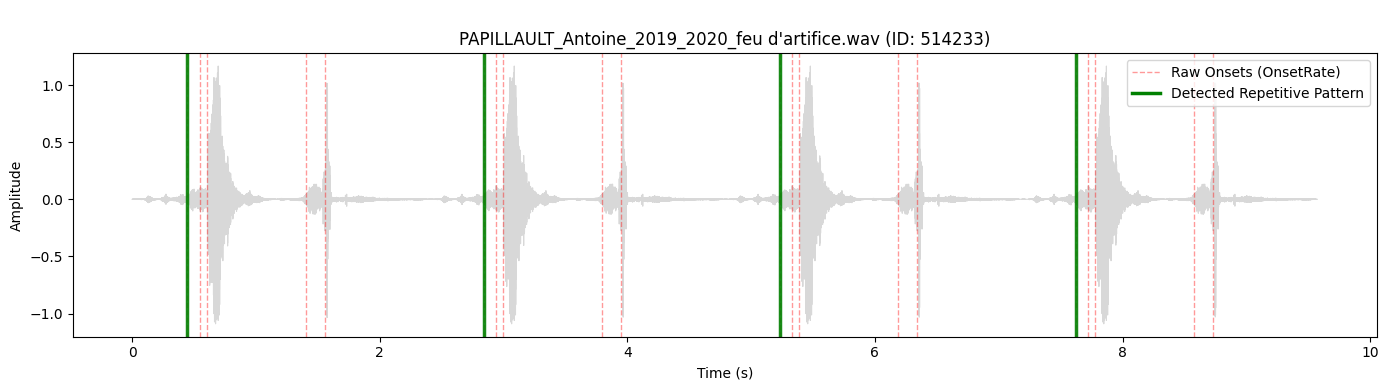

--- Analyzing: 571282_12863752-hq.ogg ---
Total raw onsets detected: 11
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 2
--> No repeating clusters found.

--- Sound ID: 571282 ---
File: 571282_12863752-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 11 | In Pattern: 0
Detected Repetitive Indices: []


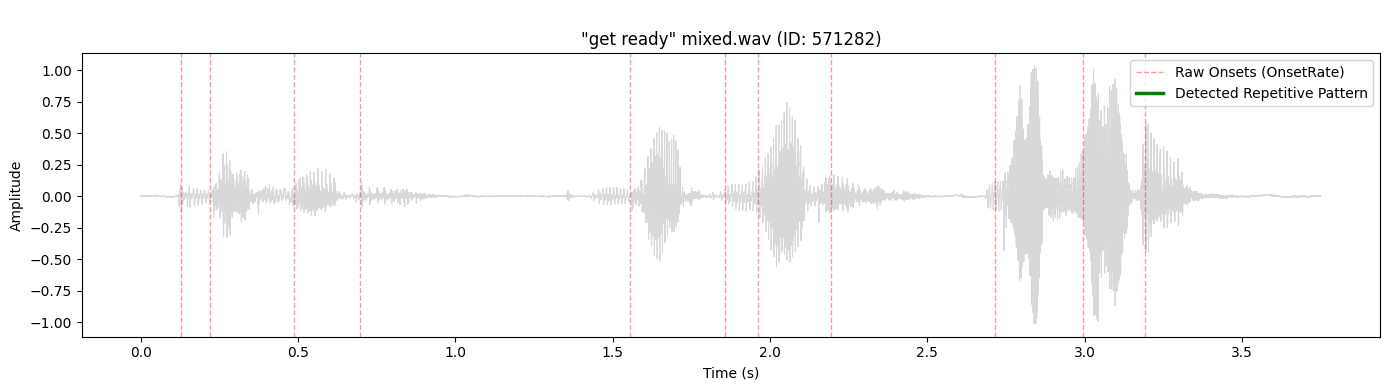

--- Analyzing: 468527_9786444-hq.ogg ---
Total raw onsets detected: 11
Onsets passing LAT (< 0.15s) & Decay (> 0.0) filters: 2
--> No repeating clusters found.

--- Sound ID: 468527 ---
File: 468527_9786444-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 11 | In Pattern: 0
Detected Repetitive Indices: []


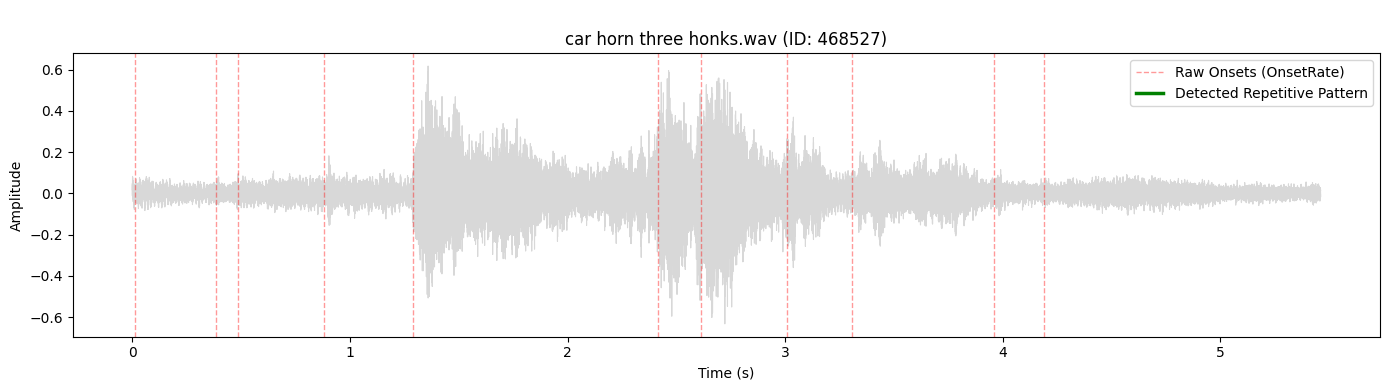


=== FINAL EVALUATION ===
Precision: 0.38 (When pipeline fired, it was right 38% of the time)
Recall:    0.39 (Pipeline found 39% of all true repetitive onsets)
F1 Score:  0.38


In [15]:
evaluate_pipeline(annotations, META_DIR)

---

### GARBAGE

In [ ]:
import os
import glob
import json
import pandas as pd
from IPython.display import display, Audio

def _build_query_map(meta_dir):
    """Internal helper to map query strings to sets of unique Freesound IDs."""
    query_to_ids = {}
    global_unique_ids = set()
    
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        json_path = csv_path.rsplit(".", 1)[0] + ".json"
        
        # Fallback to filename
        query_str = os.path.basename(csv_path) 
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    if "queries" in data and isinstance(data["queries"], list):
                        # NORMALIZATION 1: Strip whitespace from every query
                        q_list = [q.get("query", "").strip() for q in data["queries"]]
                        query_str = " + ".join(filter(None, q_list)) 
            except Exception:
                pass
                
        df = pd.read_csv(csv_path)
        if "sound_id" in df.columns:
            # NORMALIZATION 2: Use lowercase keys for internal storage
            lookup_key = query_str.lower()
            
            if lookup_key not in query_to_ids:
                # We store the 'display_name' so the table still looks nice
                query_to_ids[lookup_key] = {"display_name": query_str, "ids": set()}
            
            unique_in_csv = df["sound_id"].unique()
            query_to_ids[lookup_key]["ids"].update(unique_in_csv)
            global_unique_ids.update(unique_in_csv)
            
    return query_to_ids, global_unique_ids

# ---------------------------------------------------------
def summarize_queries(meta_dir):
    query_map, global_unique = _build_query_map(meta_dir)
    
    print(f"{'Query String':<45} | {'Unique Sounds'}")
    print("-" * 65)
    
    # Sort by the display name
    for key in sorted(query_map.keys()):
        item = query_map[key]
        print(f"{item['display_name']:<45} | {len(item['ids'])}")
        
    print("-" * 65)
    print(f"{'TOTAL ABSOLUTE UNIQUE SOUNDS':<45} | {len(global_unique)}")

# ---------------------------------------------------------
# 2. Get IDs for a Specific Query
# ---------------------------------------------------------
def print_ids_for_query(meta_dir, target_query):
    """Given a query string, prints all associated Freesound IDs beautifully."""
    query_map, _ = _build_query_map(meta_dir)
    search_key = target_query.strip().lower()
    
    if search_key in query_map:
        item = query_map[search_key]
        
        # 1. Cast to int to remove the 'np.int64' branding
        # 2. Sort them so the list isn't jumping around randomly
        clean_ids = sorted([int(sid) for sid in item["ids"]])
        
        print(f"--- {item['display_name'].upper()} ({len(clean_ids)} sounds) ---")
        
        for sid in clean_ids:
            print(sid)
            
        return clean_ids
    else:
        print(f"Query '{target_query}' not found.")
        available = [v['display_name'] for v in query_map.values()]
        print(f"Available options: {available}")
        return []

# ---------------------------------------------------------
# 3. Inspect, Plot, and Play a Specific Sound ID
# ---------------------------------------------------------
def inspect_sound(meta_dir, sound_id):
    """
    Looks up a Freesound ID, prints metadata, plots the waveform/spectrogram 
    with onsets, and displays a playable audio widget.
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        df = pd.read_csv(csv_path)
        
        if "sound_id" in df.columns:
            match = df[df["sound_id"] == sound_id]
            
            if not match.empty:
                row = match.iloc[0]
                local_path = row["local_path"]
                
                print(f"--- Sound ID: {sound_id} ---")
                print(f"Name: {row.get('name', 'N/A')}")
                print(f"Tags: {row.get('tags', 'N/A')}")
                print(f"Path: {local_path}\n")
                
                if not os.path.exists(local_path):
                    print("Error: Audio file not found on disk. Run ensure_datasets_audio().")
                    return
                
                # Run onset detection
                audio, onsets = detect_onsets(local_path)
                print(f"Detected {len(onsets)} onsets.")
                
                # Plot
                plot_waveform_with_onsets(audio, onsets)
                
                # Display playback widget
                display(Audio(local_path))
                return
                
    print(f"Sound ID {sound_id} not found in any metadata CSV.")